### 1.Libraries Importing 

pandas: Used to read and handle data in tables (like Excel files).

numpy: Helps with numbers and arrays in calculations.

matplotlib.pyplot: Draws graphs and charts.

seaborn: Makes charts look better and easier to read.

train_test_split, cross_val_score: Helps split data into training and testing parts and checks model accuracy on different parts.

StandardScaler: Makes sure all features are on the same scale.

PCA (Principal Component Analysis): Reduces the number of features while keeping most of the useful information.

accuracy_score, classification_report, confusion_matrix, roc_auc_score: Shows how good or bad the model is.

RandomForestClassifier: A strong model that uses many trees to make predictions.

KNeighborsClassifier: A model that predicts based on nearby data points.

Pipeline: Combines steps like scaling and modeling into one easy process.

LabelEncoder: Turns text labels into numbers.

SMOTE: Fixes class imbalance by making more samples of smaller classes.

variance_inflation_factor: Checks if features are too similar (multicollinearity).

pickle: Saves the trained model to use it again later.

warnings.filterwarnings('ignore'): Hides warning messages to keep the notebook clean.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pickle



### 2.Dataset loading 

df.head() shows the first 5 rows of a DataFrame.

In [2]:
df = pd.read_excel(r"C:\Users\E N V Y\Desktop\rockburst dataset of team sigma.xlsx")
print(df.head())


   peak_accel  event_rate   b_value  signal_energy  duration  dominant_freq  \
0    0.812575           2  1.628524            131         5            165   
1    0.752866           2  1.959038            249        13            168   
2    0.810998           2  1.661275            203         5            158   
3    0.636414           1  1.680068            184         6            176   
4    0.771169           4  1.688472            278        10            182   

   brittleness  stress  elastic_energy  compressive_strength  \
0     0.450684      79             241                    33   
1     0.497278      62             269                    48   
2     0.470248      45             138                    58   
3     0.423906      60             174                    32   
4     0.474761      44             252                    46   

   tensile_strength  grade  
0                 8      3  
1                 8      3  
2                 9      1  
3                11     

### 3.information about the dataset 

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   peak_accel            400 non-null    float64
 1   event_rate            400 non-null    int64  
 2   b_value               400 non-null    float64
 3   signal_energy         400 non-null    int64  
 4   duration              400 non-null    int64  
 5   dominant_freq         400 non-null    int64  
 6   brittleness           400 non-null    float64
 7   stress                400 non-null    int64  
 8   elastic_energy        400 non-null    int64  
 9   compressive_strength  400 non-null    int64  
 10  tensile_strength      400 non-null    int64  
 11  grade                 400 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 37.6 KB


### 4.Grade Distribution 

grade
3    100
1    100
4    100
2    100
Name: count, dtype: int64


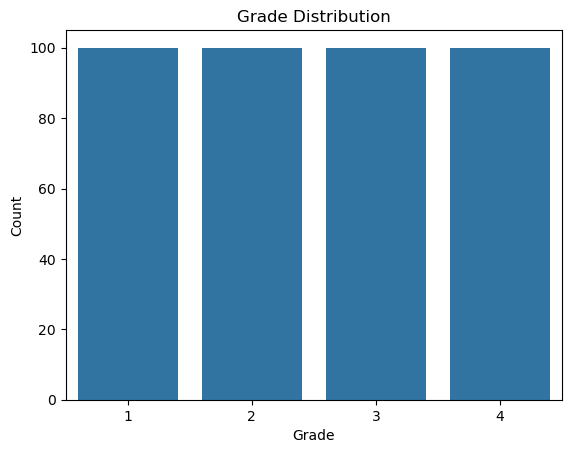

In [4]:
print(df['grade'].value_counts())
sns.countplot(data=df, x='grade')
plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()


###  5.Correlation Matrix 

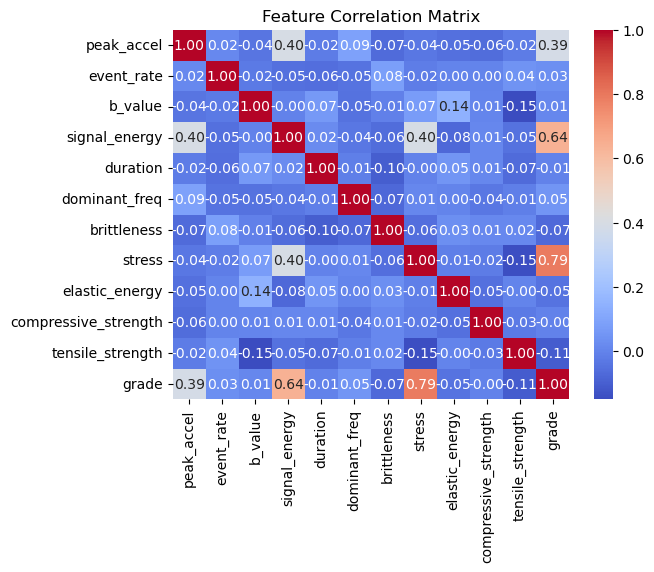

In [5]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


### 6.VIF Analysis For Multicollinearity 

To detect multicollinearity (high correlation between features), we use Variance Inflation Factor (VIF).
First, we drop the target column (grade) and select only numeric features.
Then for each feature, VIF is calculated.
A VIF > 10 usually means that the feature is highly collinear with others.
High multicollinearity can negatively impact model performance and interpretability.

In [ ]:
X = df.drop('grade', axis=1)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


                 feature         VIF
0             peak_accel   10.234636
1             event_rate    5.923445
2                b_value  120.423349
3          signal_energy   10.398604
4               duration   11.469464
5          dominant_freq  108.338593
6            brittleness  153.731044
7                 stress   14.807511
8         elastic_energy   14.088887
9   compressive_strength   25.239449
10      tensile_strength   62.532979


### 7.Standard Scaling apply 
To normalize all features to the same scale.
Needed because models like KNN and PCA are distance-based — they get biased by features with large scales.



In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### 7.PCA To Reduce Multicollinearity 


PCA (Principal Component Analysis) is a technique used to reduce the number of features while retaining most of the variance in the data.
n_components=0.95 means we keep only enough components to retain 95% of the original variance, reducing multicollinearity and dimensionality

In [8]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(f"Original features: {X.shape[1]}")
print(f"PCA components after reduction: {X_pca.shape[1]}")


Original features: 11
PCA components after reduction: 10


### 8.train and test slpit 
We split the dataset into training and testing sets using train_test_split, with 20% for testing.
The stratify=y parameter ensures each class (grade) is proportionally represented in both sets.

In [9]:
y = df['grade']
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)


### 9.Apply SMOTE 

SMOTE (Synthetic Minority Oversampling Technique) is applied only to the training data to balance class distributions by creating synthetic examples for minority classes.

In [10]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


### 10.Class Distribution 

In [11]:
print("Train:", y_train_res.value_counts())
print("Test:", y_test.value_counts())


Train: grade
2    80
3    80
1    80
4    80
Name: count, dtype: int64
Test: grade
3    20
2    20
1    20
4    20
Name: count, dtype: int64


### 11.Random Forest Model 

### Traning 

In [12]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)


RandomForestClassifier(random_state=42)

### 12.make prediction 

In [13]:
y_pred_rf = rf_model.predict(X_test)


### 13.evaluate performance 

In [14]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7875

Classification Report:
               precision    recall  f1-score   support

           1       0.69      0.55      0.61        20
           2       0.69      0.90      0.78        20
           3       0.82      0.70      0.76        20
           4       0.95      1.00      0.98        20

    accuracy                           0.79        80
   macro avg       0.79      0.79      0.78        80
weighted avg       0.79      0.79      0.78        80



### 14.confusion metrix 

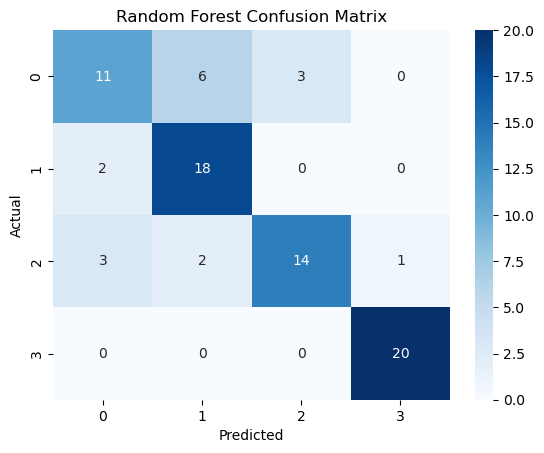

In [15]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, cmap='Blues', fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### 15.ROC AUC Score (Macro-Averaged)

In [16]:
print("ROC AUC (macro):", roc_auc_score(
    y_test, rf_model.predict_proba(X_test), multi_class='ovo', average='macro'
))


ROC AUC (macro): 0.9574999999999999


### 16.Feature Importance Of Random Forest 

In [17]:
importances = rf_model.feature_importances_
components = [f'PC{i+1}' for i in range(len(importances))]


### 17.Plot feature importance

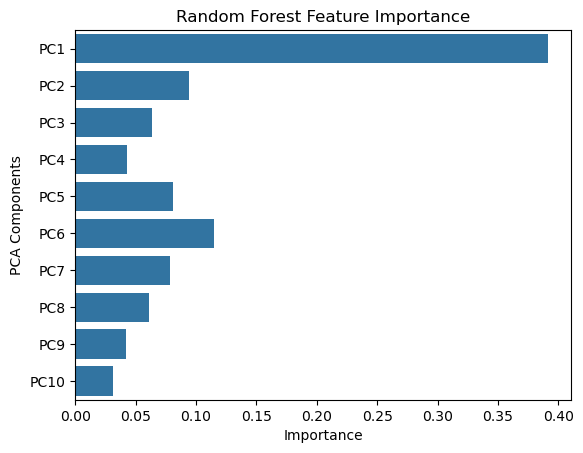

In [18]:
sns.barplot(x=importances, y=components)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("PCA Components")
plt.show()


### 18.Initialize and Train KNN

In [19]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_res, y_train_res)


KNeighborsClassifier()

### 19.Predict + Accuracy Report

In [20]:
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.825

Classification Report:
               precision    recall  f1-score   support

           1       0.64      0.70      0.67        20
           2       0.84      0.80      0.82        20
           3       0.84      0.80      0.82        20
           4       1.00      1.00      1.00        20

    accuracy                           0.82        80
   macro avg       0.83      0.82      0.83        80
weighted avg       0.83      0.82      0.83        80



### 20. Confusion Matrix + ROC AUC

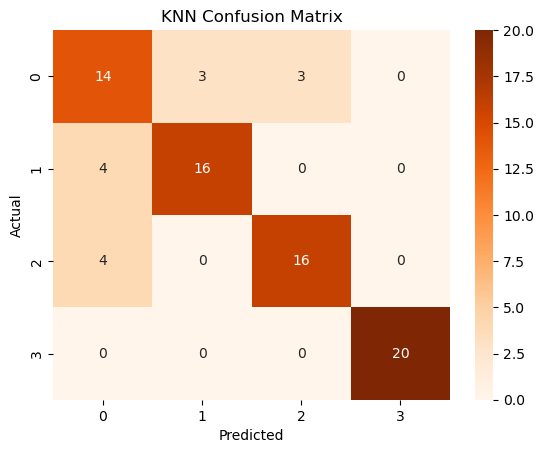

ROC AUC (macro): 0.9423958333333333


In [21]:
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, cmap='Oranges', fmt='d')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("ROC AUC (macro):", roc_auc_score(y_test, knn.predict_proba(X_test), multi_class='ovo', average='macro'))


### 21.Cross Validation On Random Forest 

Purpose: To check how well the model generalizes to unseen data.
We apply 5-fold cross-validation using cross_val_score, which splits the dataset into 5 parts, trains on 4, and tests on 1 — repeating this process 5 times.
The accuracy score is calculated in each fold and then averaged.

In [22]:
cv_scores = cross_val_score(rf_model, X_pca, y, cv=5, scoring='accuracy')
print(cv_scores)
print("Average Accuracy:", cv_scores.mean())


[0.8375 0.9    0.875  0.85   0.8375]
Average Accuracy: 0.86


### 22.Cross Validation For KNN Model 

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn_cv_scores = cross_val_score(knn, X_pca, y, cv=5)
print("KNN CV scores:", knn_cv_scores)
print("KNN Average CV Accuracy:", knn_cv_scores.mean())


KNN CV scores: [0.85   0.85   0.8375 0.8    0.8   ]
KNN Average CV Accuracy: 0.8275


### 23.Model Saving 

After training our models, we save them for later use (e.g., for deployment in a Streamlit dashboard). We use the pickle library for this purpose.
pickle.dump() is used to serialize and save the model object.
"wb" means write in binary mode, which is required when saving non-text files.

In [36]:
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
with open("knn_model.pkl", "wb") as f:
    pickle.dump(knn, f)
print("Models saved as .pkl files")


Models saved as .pkl files
